
# Brisk-Light Black Hole Imaging from GRMHD Simulations

Movie generation with the brisk-light prescription, parameterised by the retained
probability mass `p`:

- `p = 0`   every step of band *n* is evaluated at the modal time `t̄_n`
- `0 < p < 1`   step times inside the modal HDI are kept, tails clipped to the edge
- `p = 1`   clipping bypassed; reduces to slow light within the loaded snapshot window

Geodesics are traced once and reused for every frame and every `p`.

In [1]:
using Jipole
using StaticArrays
using Printf
using Statistics
using DelimitedFiles
using ProgressMeter

const MBH = 6.2e9          # M87*, solar masses

println("Julia threads available: ", Threads.nthreads())

Julia threads available: 16


In [5]:
# Portable paths. Everything below is derived from DATA_DIR, so the notebook runs
# unchanged on Windows and on Delta.

const DATA_DIR       = joinpath("..", "..", "data")
const all_dumps_path = joinpath(DATA_DIR, "kharma_dumps", "tmp.%05d.h5")
const IMAGES_DIR      = joinpath(DATA_DIR, "Images")
const SLOW_DIR        = joinpath(IMAGES_DIR, "SlowLight")

mkpath(IMAGES_DIR)
println("dumps  : ", all_dumps_path)
println("images : ", IMAGES_DIR)

dumps  : ..\..\data\kharma_dumps\tmp.%05d.h5
images : ..\..\data\Images


In [7]:
const dump_first   = 0
const dump_last    = 10
const ImageCadence = 10.0

dump_list  = [Printf.format(Printf.Format(all_dumps_path), i) for i in dump_first:dump_last]
dump_times = [Jipole.Brisklight.get_dump_time(i, all_dumps_path) for i in dump_first:dump_last]

@assert issorted(dump_times) "dump_times must be ascending."
const dT = dump_times[2] - dump_times[1]

println("Total dumps available : ", length(dump_list))
@printf("Time range            : %.3f M  ->  %.3f M\n", dump_times[1], dump_times[end])
@printf("Dump spacing dT       : %.3f M\n", dT)

Total dumps available : 11
Time range            : 1100.003 M  ->  2100.006 M
Dump spacing dT       : 100.004 M


In [8]:
trat_large           = 20.0
const trat_small     = 1.0
const beta_crit      = 1.0
const th_beg         = 1.74e-2      # ~1 deg polar cone excluded
const sigma_cut      = 1.0
const sigma_cut_high = -1.0

-1.0

In [9]:
println("Initializing grid from: ", dump_list[1])

model = Jipole.Iharm.read_header(
    dump_list[1], MBH;
    brisk_light    = true,
    slow_light     = false,
    trat_small     = trat_small,
    beta_crit      = beta_crit,
    th_beg         = th_beg,
    sigma_cut      = sigma_cut,
    sigma_cut_high = sigma_cut_high
)

# The local iharm.jl patch that gates time interpolation on
# (model.slow_light || model.brisk_light) instead of model.slow_light alone
# must be applied for these flags to have any effect.
@assert model.brisk_light  "model.brisk_light must be true"
@assert !model.slow_light  "model.slow_light must be false when rendering brisk light"

@printf("Model OK.  a = %.4f   rmin_geo = %.2f   rmax_geo = %.2f\n",
        model.a, model.rmin_geo, model.rmax_geo)

Initializing grid from: ..\..\data\kharma_dumps\tmp.00000.h5
Initializing grid from: ..\..\data\kharma_dumps\tmp.00000.h5


custom electron model loaded from dump file...
Using Funky Modified Kerr-Schild coordinates FMKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.001876 Rout: 1000.000000
FMKS parameters poly_xt: 0.820000 poly_alpha: 14.000000 mks_smooth: 0.500000 poly_norm: 0.757817
Grid start (startx): 1.874000951149755e-03, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 5.395219748461709e-02, 7.812500000000000e-03, 6.283185307179586e+00


Model OK.  a = 0.9375   rmin_geo = 1.00   rmax_geo = 100.00


In [10]:
const ro  = 1000.0
const th  = 163.0            # colatitude of the camera
const phi = 0.0

const pixels_x = 128
const pixels_y = 128

const SourceD = 16.9e6 * Jipole.Constants.PC
const Rh      = 1.0 + sqrt(1.0 - model.a * model.a)
const freq    = 230e9
const FOV_uas = 160.0

const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * FOV_uas
const DYsize = DXsize
const fovx   = DXsize / ro
const fovy   = DYsize / ro

println("Resolution     : $pixels_x x $pixels_y")
@printf("Inclination    : theta = %.1f deg  (%.1f deg from the spin axis)\n", th, 180.0 - th)
@printf("Spin           : a = %.4f   (horizon Rh = %.4f M)\n", model.a, Rh)
@printf("Frequency      : %.1f GHz\n", freq / 1e9)

Resolution     : 128 x 128
Inclination    : theta = 163.0 deg  (17.0 deg from the spin axis)
Spin           : a = 0.9375   (horizon Rh = 1.3480 M)
Frequency      : 230.0 GHz


In [11]:
Xcamera = MVector{4,Float64}(Jipole.Camera.camera_position(ro, th, phi, model.a, model))

const freq_unitless = freq * Jipole.Constants.HPL /
                      (Jipole.Constants.ME * Jipole.Constants.CL * Jipole.Constants.CL)

nsteps             = zeros(Int, pixels_x, pixels_y)
midplane_crossings = zeros(Int, pixels_x, pixels_y)

128×128 Matrix{Int64}:
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0   

In [12]:
# Trace all geodesics once, reused for every frame and every p. In the same
# pass, compute the observer-time bounds the render needs:
#   tgeof : oldest source time any geodesic needs  -> t_obs starts at tA - tgeof
#   tgeoi : newest source time any geodesic needs  -> t_obs stops at tf - rmax_geo - tgeoi

const maxnstep = 25000
dummy_svec = @SVector zeros(4)
dummy_traj = Jipole.GeoTypes.OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)

task_trajs = [Vector{Jipole.GeoTypes.OfTrajS}(undef, maxnstep) for _ in 1:pixels_x]
for i in 1:pixels_x, k in 1:maxnstep
    task_trajs[i][k] = dummy_traj
end

const all_geodesics = Matrix{Vector{Jipole.GeoTypes.OfTrajS}}(undef, pixels_x, pixels_y)

row_tgeoi = fill(-1e100, pixels_x)
row_tgeof = zeros(Float64, pixels_x)

const LOG_RMAX = log(model.rmax_geo)

println("Tracing geodesics...")
pbar = Progress(pixels_x * pixels_y; desc = "Raytracing", showspeed = true, barlen = 30)

Threads.@threads for i in 0:(pixels_x - 1)
    my_traj = task_trajs[i + 1]

    for j in 0:(pixels_y - 1)
        nstep, midplane_crossings[i+1, j+1] = Jipole.Geodesics.get_pixel(
            my_traj, i, j, Xcamera, fovx, fovy, freq_unitless,
            pixels_x, pixels_y, model.a, Rh, model.rmax_geo, model)
        nsteps[i+1, j+1] = nstep
        all_geodesics[i+1, j+1] = my_traj[1:nstep]

        final_step_time = my_traj[nstep].X[1]

        pixel_tgeoi = 1.0
        pixel_tgeof = 1.0
        for k in 1:nstep
            X = my_traj[k].X; K = my_traj[k].Kcon
            log_r = X[2]; t_coord = X[1]; k_r = K[2]
            if pixel_tgeoi > 0.0 && log_r < LOG_RMAX
                pixel_tgeoi = t_coord
            end
            if pixel_tgeof > 0.0 && log_r > LOG_RMAX && k_r < 0.0
                pixel_tgeof = t_coord
            end
        end
        if pixel_tgeoi < 0.0 && pixel_tgeoi > row_tgeoi[i+1]
            row_tgeoi[i+1] = pixel_tgeoi
        end
        if pixel_tgeof < 0.0 && pixel_tgeof < row_tgeof[i+1]
            row_tgeof[i+1] = pixel_tgeof
        elseif pixel_tgeof > 0.0 && final_step_time < row_tgeof[i+1]
            row_tgeof[i+1] = final_step_time
        end

        ProgressMeter.next!(pbar)
    end
end
finish!(pbar)

const tgeof = minimum(row_tgeof)
const tgeoi = maximum(row_tgeoi)

@printf("tgeof = %10.3f M   (oldest source time needed)\n", tgeof)
@printf("tgeoi = %10.3f M   (newest source time needed)\n", tgeoi)

Tracing geodesics...


Raytracing 100%|██████████████████████████████| Time: 0:00:12 ( 0.73 ms/it)


tgeof =  -1170.568 M   (oldest source time needed)
tgeoi =   -909.350 M   (newest source time needed)


In [13]:
# Precompute, once, what the render loop otherwise recomputes on every frame
# and every p: the per-step radiating flag and bin index (band n=0..n_bands,
# plus the approach/shadow auxiliary bins), and the modal HDI per bin.

const n_bands = 3

params_brisklight = Jipole.Brisklight.OfBriskLight(n_bands, 1.0, ImageCadence)

step_radiating, step_bin = Jipole.Brisklight.precompute_step_info(
    midplane_crossings, all_geodesics, nsteps, pixels_x, pixels_y,
    n_bands, model, Rh; approach_bin = true, shadow_bin = true)

band_ts, ranges = Jipole.Brisklight.compute_band_modal_times!(
    midplane_crossings, all_geodesics, nsteps, pixels_x, pixels_y,
    params_brisklight, model, 1.0;
    pixel_stride   = 4,
    extrema_stride = 1,
    approach_bin   = true,
    shadow_bin     = true,
    verbose        = false)

([[-1021.7970067940682, -1021.5522532980134, -1021.3054995513709, -1021.0560323632216, -1020.8031209135694, -1020.5460213060245, -1020.2839802898837, -1020.0162379117002, -1019.7420288948689, -1019.4605825859528  …  -920.8857750894238, -920.1090752236599, -919.3270356177617, -918.5396034841172, -917.7467255522128, -916.9483480619908, -916.1444167571622, -915.3348768784726, -914.5196731569226, -913.6987498069385], [-1113.7010929180065, -1112.9627141954204, -1112.2315571058734, -1111.5075485609907, -1110.7906161766666, -1110.0806882663255, -1109.3776938342692, -1108.6815625691124, -1107.9922248373039, -1107.309611676733  …  -1022.5955932768118, -1022.5241595223813, -1022.453180516883, -1022.3825952301148, -1022.3123395494938, -1022.242346639475, -1022.17254735613, -1022.1028707124202, -1022.0332443876902, -1021.9635952729959], [-1060.002676220684, -1059.9729054193078, -1059.9431231327533, -1059.9133255723975, -1059.8835089745476, -1059.8536696113947, -1059.8238038017207, -1059.7939079212

In [14]:
# Observer-time grid, pinned to the same bounds slow light would use so that
# runs at different p stay on a comparable schedule.

tA = dump_times[1]
tB = dump_times[end]
tf = dump_times[end]

const T_OBS_START = tA - tgeof
const T_OBS_STOP  = min(tB, tf - model.rmax_geo) - tgeoi

@printf("t_obs grid: %.3f : %.1f : %.3f M  (%d frames)\n",
        T_OBS_START, ImageCadence, T_OBS_STOP,
        max(0, floor(Int, (T_OBS_STOP - T_OBS_START) / ImageCadence) + 1))

t_obs grid: 2270.570 : 10.0 : 2909.356 M  (64 frames)



## Render

Writes one text image per frame plus a `frames.csv` manifest recording the
exact `t_obs`, the clamped fraction, and the number of dump loads.

In [ ]:
P_TEST = 0.0

params_brisklight.p = P_TEST
out_dir = joinpath(IMAGES_DIR, "BriskLight_p$(P_TEST)")

@printf("\nRendering brisk light, p = %.2f\n", P_TEST)
println("  output : ", out_dir)

res = Jipole.Brisklight.process_brisklight_images!(
    params_brisklight,
    all_geodesics, nsteps, midplane_crossings, model,
    pixels_x, pixels_y, freq, trat_large,
    dump_list, dump_times, tA, tB, tf;
    t_obs_start    = T_OBS_START,
    t_obs_stop     = T_OBS_STOP,
    output_dir     = out_dir,
    band_ts        = band_ts,
    ranges         = ranges,
    step_radiating = step_radiating,
    step_bin       = step_bin,
    anchor         = :mode,
    n_window       = 3)

@printf("\n%d frames, mean clamped fraction %.4f, %d dump loads total\n",
        res.frames, mean(filter(isfinite, res.clamped)), sum(res.loads))


Rendering brisk light, p = 0.00
  output : ..\..\data\Images\BriskLight_p0.0
Loading data from '..\..\data\kharma_dumps\tmp.00000.h5' into 'Iharm' module...


┌ Warning: dump_times are not uniformly spaced; W/dT diagnostics lose their meaning.
└ @ Jipole.Brisklight C:\Users\danyp\OneDrive\Escritorio\CosasPater\jipoleProyect\Jipole\src\brisklight.jl:1047
[ Info: Brisk-light: p = 0.000  retained support = [-1082.181, -1007.624] M (width 74.557 M, 0.75 dT)
[ Info: Brisk-light: observer grid t_obs = 2270.570 : 10.000 : 2909.356 M


All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '..\..\data\kharma_dumps\tmp.00001.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '..\..\data\kharma_dumps\tmp.00002.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '..\..\data\kharma_dumps\tmp.00003.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


brisk p=0.00 t_obs=2270.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2280.6 M 100%|██████████████████████████████| Time: 0:00:01 (94.54 μs/it)
brisk p=0.00 t_obs=2290.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2300.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2310.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2320.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2330.6 M 100%|██████████████████████████████| Time: 0:00:01 (94.24 μs/it)
brisk p=0.00 t_obs=2340.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2350.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2360.6 M 100%|██████████████████████████████| Time: 0:00:01 (98.51 μs/it)
brisk p=0.00 t_obs=2370.6 M 100%|██████████████████████████████| Time:

Loading data from '..\..\data\kharma_dumps\tmp.00004.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


...

brisk p=0.00 t_obs=2510.6 M 100%|██████████████████████████████| Time: 0:00:01 (92.22 μs/it)
brisk p=0.00 t_obs=2520.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2530.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2540.6 M 100%|██████████████████████████████| Time: 0:00:01 (93.44 μs/it)
brisk p=0.00 t_obs=2550.6 M 100%|██████████████████████████████| Time: 0:00:01 (98.08 μs/it)
brisk p=0.00 t_obs=2560.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2570.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2580.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2590.6 M 100%|██████████████████████████████| Time: 0:00:01 (96.19 μs/it)
brisk p=0.00 t_obs=2600.6 M 100%|██████████████████████████████| Time: 0:00:01 (95.89 μs/it)


Loading data from '..\..\data\kharma_dumps\tmp.00006.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


brisk p=0.00 t_obs=2610.6 M 100%|██████████████████████████████| Time: 0:00:01 (96.50 μs/it)
brisk p=0.00 t_obs=2620.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.10 ms/it)
brisk p=0.00 t_obs=2630.6 M 100%|██████████████████████████████| Time: 0:00:01 (96.37 μs/it)
brisk p=0.00 t_obs=2640.6 M 100%|██████████████████████████████| Time: 0:00:01 (98.75 μs/it)
brisk p=0.00 t_obs=2650.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2660.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2670.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2680.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2690.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2700.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)


Loading data from '..\..\data\kharma_dumps\tmp.00007.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


brisk p=0.00 t_obs=2710.6 M 100%|██████████████████████████████| Time: 0:00:02 ( 0.13 ms/it)
brisk p=0.00 t_obs=2720.6 M 100%|██████████████████████████████| Time: 0:00:02 ( 0.12 ms/it)
brisk p=0.00 t_obs=2730.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2740.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2750.6 M 100%|██████████████████████████████| Time: 0:00:01 ( 0.11 ms/it)
brisk p=0.00 t_obs=2760.6 M   3%|█                             |  ETA: 0:00:05 ( 0.33 ms/it)


## Comparison with slow light

Frames are paired by observer time, not by list position: slow light silently
drops frames whose integration never completes, so the two file lists can
desynchronise.

In [18]:
P_TEST = 0.0

0.0

In [19]:
using CairoMakie

function read_manifest(dir::String)
    f = joinpath(dir, "frames.csv")
    isfile(f) || return nothing
    t = Float64[]; path = String[]
    for l in readlines(f)[2:end]
        isempty(strip(l)) && continue
        parts = split(strip(l), ',')
        push!(t, parse(Float64, parts[2]))
        push!(path, joinpath(dir, String(parts[3])))
    end
    o = sortperm(t)
    return (t_obs = t[o], path = path[o])
end

# Slow light has no manifest: process_slowlight_images! names each file after its
# target observer time, so the filename IS the time (rounded).
function scan_frames(dir::String; prefix = "Image.")
    isdir(dir) || return (t_obs = Float64[], path = String[])
    fs = filter(f -> startswith(basename(f), prefix) && endswith(f, ".txt"),
                readdir(dir, join = true))
    t = Float64[]; keep = String[]
    for f in fs
        m = match(r"(\d+)(?=\.txt$)", basename(f))
        m === nothing && continue
        push!(t, parse(Float64, m.match)); push!(keep, f)
    end
    o = sortperm(t)
    return (t_obs = t[o], path = keep[o])
end

frames_of(dir; prefix = "BriskImage.") =
    something(read_manifest(dir), scan_frames(dir; prefix = prefix))

# tol defaults to half a cadence: brisk stores the exact float, slow light only
# the rounded integer in its filename, so an exact match is not expected.
function pair_by_time(A, B; tol = 0.5 * ImageCadence)
    pairs = NamedTuple[]
    for (i, t) in enumerate(A.t_obs)
        d, j = findmin(abs.(B.t_obs .- t))
        d <= tol && push!(pairs, (t_obs = t, a = A.path[i], b = B.path[j], dt = B.t_obs[j] - t))
    end
    return pairs
end

nmse(Iref, Itst) = sum((Iref .- Itst).^2) / sum(Iref.^2)

brisk = frames_of(joinpath(IMAGES_DIR, "BriskLight_p$(P_TEST)"))
slow  = frames_of(SLOW_DIR; prefix = "Image.")

@printf("brisk frames: %d   t_obs in [%.1f, %.1f]\n",
        length(brisk.t_obs), minimum(brisk.t_obs; init = NaN), maximum(brisk.t_obs; init = NaN))
@printf("slow  frames: %d   t_obs in [%.1f, %.1f]\n",
        length(slow.t_obs), minimum(slow.t_obs; init = NaN), maximum(slow.t_obs; init = NaN))

pairs = pair_by_time(brisk, slow)
@printf("matched %d frames on a common observer window\n", length(pairs))

if isempty(pairs)
    @warn "No common observer times. Re-render slow light on the same grid, or check that SLOW_DIR points at the right run."
end

brisk frames: 49   t_obs in [NaN, NaN]
slow  frames: 64   t_obs in [NaN, NaN]
matched 49 frames on a common observer window


cross-correlation peaks at lag = -1 frames (-10.0 M)


┌ Warning: FAIL - constant offset between the runs; fix t_obs_start before interpreting residuals
└ @ Main In[20]:20


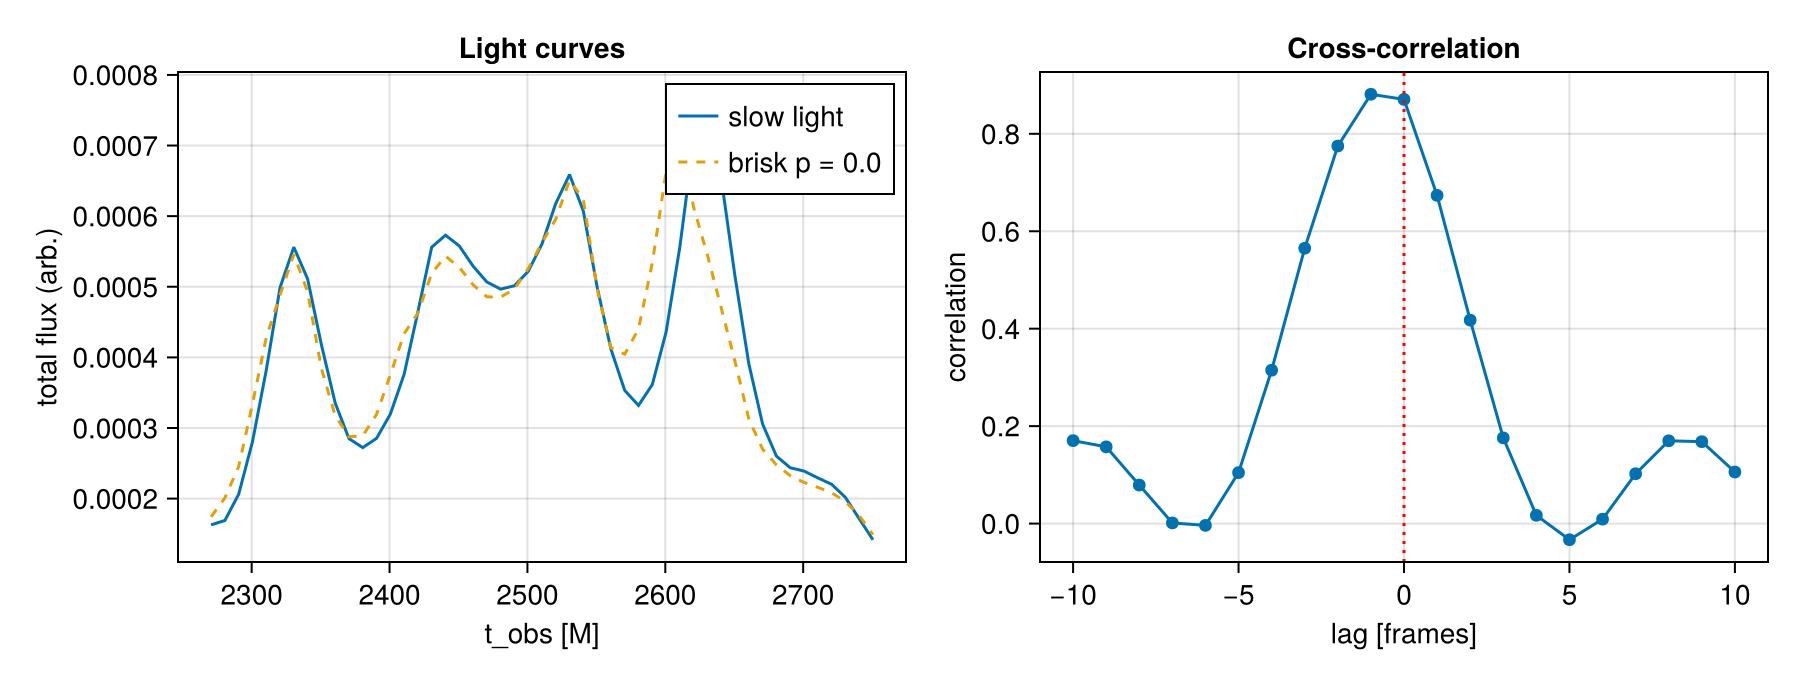

In [20]:
# --- Before trusting any NMSE: is there a constant lag? ----------------------
# A pure time offset between the two runs looks like a huge NMSE. If the cross
# correlation of the light curves does not peak at zero lag, the problem is
# synchronisation, not physics.

if length(pairs) >= 4
    F_brisk = [sum(readdlm(p.a)) for p in pairs]
    F_slow  = [sum(readdlm(p.b)) for p in pairs]
    t_pair  = [p.t_obs for p in pairs]

    zb = (F_brisk .- mean(F_brisk)) ./ std(F_brisk)
    zs = (F_slow  .- mean(F_slow))  ./ std(F_slow)
    n  = length(zb)
    lags = -min(10, n ÷ 3):min(10, n ÷ 3)
    xc = [mean(zb[max(1,1+l):min(n,n+l)] .* zs[max(1,1-l):min(n,n-l)]) for l in lags]
    best = lags[argmax(xc)]

    @printf("cross-correlation peaks at lag = %d frames (%.1f M)\n", best, best * ImageCadence)
    best == 0 ? println("PASS - the two runs are synchronised") :
                @warn "FAIL - constant offset between the runs; fix t_obs_start before interpreting residuals"

    fig = Figure(size = (900, 340))
    ax  = Axis(fig[1,1], xlabel = "t_obs [M]", ylabel = "total flux (arb.)",
               title = "Light curves")
    lines!(ax, t_pair, F_slow,  label = "slow light")
    lines!(ax, t_pair, F_brisk, label = "brisk p = $(P_TEST)", linestyle = :dash)
    axislegend(ax)
    ax2 = Axis(fig[1,2], xlabel = "lag [frames]", ylabel = "correlation",
               title = "Cross-correlation")
    scatterlines!(ax2, collect(lags), xc)
    vlines!(ax2, [0], color = :red, linestyle = :dot)
    fig
else
    @warn "need at least 4 paired frames for the lag check"
end

In [21]:
# --- Comparison movie --------------------------------------------------------

function comparison_gif(pairs, gif_path; label_a = "A", label_b = "B",
                        vmin = 1e-12, vmax = 1e-5, eps_val = 1e-30, framerate = 10)
    isempty(pairs) && (@warn "nothing to render"; return)

    # Sanity on the colour scale: a fixed range that misses the data makes every
    # frame look saturated or empty without any warning.
    I0 = readdlm(pairs[1].b)
    @printf("first frame intensity range: [%.3e, %.3e]  (colour scale [%.0e, %.0e])\n",
            minimum(filter(>(0), I0); init = NaN), maximum(I0), vmin, vmax)

    fig = Figure(size = (1800, 500))
    record(fig, gif_path, 1:length(pairs); framerate = framerate) do i
        empty!(fig)
        pr = pairs[i]
        Iref = readdlm(pr.b)
        Itst = readdlm(pr.a)
        size(Itst) == size(Iref) || (Itst = reshape(Itst, size(Iref)))

        rel = abs.(Itst .- Iref) ./ (abs.(Iref) .+ eps_val)
        m   = nmse(Iref, Itst)

        ax1 = Axis(fig[1,1], title = @sprintf("%s | t_obs = %.1f M", label_b, pr.t_obs))
        h1 = heatmap!(ax1, Iref, colormap = :afmhot, colorscale = log10, colorrange = (vmin, vmax))
        Colorbar(fig[1,2], h1)

        ax2 = Axis(fig[1,3], title = @sprintf("%s | t_obs = %.1f M", label_a, pr.t_obs))
        h2 = heatmap!(ax2, Itst, colormap = :afmhot, colorscale = log10, colorrange = (vmin, vmax))
        Colorbar(fig[1,4], h2)

        ax3 = Axis(fig[1,5], title = "Relative error")
        h3 = heatmap!(ax3, rel, colormap = :viridis, colorscale = log10, colorrange = (1e-6, 10.0))
        Colorbar(fig[1,6], h3)
        text!(ax3, 0.05, 0.95; text = @sprintf("NMSE = %.2e", m), space = :relative,
              color = :white, fontsize = 16, font = :bold, align = (:left, :top))
    end
    println("GIF saved -> ", gif_path)
end

comparison_gif(pairs, joinpath(IMAGES_DIR, "comparison_brisk_p$(P_TEST)_vs_slow.gif");
               label_a = "Brisk p = $(P_TEST)", label_b = "Slow light")

first frame intensity range: [NaN, 4.654e-06]  (colour scale [1e-12, 1e-05])
GIF saved -> ..\..\data\Images\comparison_brisk_p0.0_vs_slow.gif
